# Tutorial: SciPy for Quantitative Finance Mastery Guide

Audience:
- Learners who know NumPy/pandas and want the scientific-computing tools that sit underneath much quantitative finance work.
- Financial-engineering students who want practical SciPy patterns rather than a tour of every submodule.

Prerequisites:
- Python, NumPy arrays, pandas DataFrames, and basic probability/statistics.
- The broad ideas of covariance, portfolio weights, returns, discounting, and optimisation.

Learning goals:
- Use `scipy.stats` for distributions, risk summaries, and hypothesis tests.
- Use `scipy.optimize` for constrained portfolio optimisation and root finding.
- Use `scipy.linalg` for covariance-matrix decomposition and linear systems.
- Use `scipy.signal` for causal smoothing and spectral inspection.
- Use `scipy.interpolate` and `scipy.integrate` for curve construction and discounting.
    

## Outline

1. Create synthetic market, asset-return, and yield-curve data
2. Explore distributions, confidence intervals, tests, and Value at Risk
3. Build a constrained minimum-variance portfolio
4. Use eigenvalue decomposition and a linear solve on the covariance matrix
5. Smooth and inspect a time series with signal tools
6. Interpolate a zero curve, discount cash flows, and solve for a zero rate

SciPy is the numerical and statistical layer of the Python ecosystem. It complements pandas, scikit-learn, and PyTorch; it does not replace them.
    

In [1]:
from __future__ import annotations

# If your kernel does not have SciPy yet, uncomment the next line.
# %pip install numpy pandas matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy import integrate, interpolate, linalg, optimize, signal, stats

SEED = 42
rng = np.random.default_rng(SEED)

print("SciPy version:", scipy.__version__)
print("Seed:", SEED)
    

SciPy version: 1.17.1
Seed: 42


## Step 1 - Build reproducible market data

We create daily returns for five synthetic assets driven by three common factors. The returns have correlation, regime-like variation, and idiosyncratic noise. A separate sparse zero curve gives us an interpolation problem later.

The data are only a controlled teaching environment. Nothing here is an investment recommendation.
    

In [2]:
n_days = 1_500
dates = pd.bdate_range("2020-01-01", periods=n_days)
asset_names = ["Equity", "Value", "Momentum", "Bonds", "Commodity"]

time = np.arange(n_days)
market_factor = 0.00025 + 0.010 * rng.standard_t(df=6, size=n_days)
value_factor = 0.00005 + 0.005 * np.sin(time / 75) + 0.006 * rng.standard_normal(n_days)
carry_factor = 0.00008 + 0.004 * np.cos(time / 50) + 0.005 * rng.standard_normal(n_days)
factors = np.column_stack([market_factor, value_factor, carry_factor])

factor_loadings = np.array(
    [
        [1.10, 0.20, 0.05],
        [0.85, 0.75, 0.10],
        [0.80, -0.10, 0.80],
        [-0.20, 0.05, 0.15],
        [0.35, 0.10, -0.45],
    ]
)
idiosyncratic_volatility = np.array([0.009, 0.008, 0.010, 0.004, 0.011])
asset_returns = factors @ factor_loadings.T + rng.normal(0, idiosyncratic_volatility, size=(n_days, 5))
returns = pd.DataFrame(asset_returns, index=dates, columns=asset_names)

# A simple strategy and benchmark support the statistical examples below.
strategy_returns = 0.00018 + 0.55 * returns["Momentum"] + 0.20 * returns["Value"] + rng.normal(0, 0.004, n_days)
benchmark_returns = 0.50 * returns["Equity"] + 0.15 * returns["Bonds"] + rng.normal(0, 0.003, n_days)
active_returns = (strategy_returns - benchmark_returns).rename("active_return")

returns.head()
    

,Equity,Value,Momentum,Bonds,Commodity
2020-01-01,0.013922,0.007364,0.015120,-0.005360,-0.030969
2020-01-02,0.013889,0.010842,0.009936,-0.004633,0.021314
2020-01-03,-0.003965,0.003155,0.013631,0.008205,-0.007868
2020-01-06,0.001416,-0.012212,0.025808,-0.000004,0.005422
2020-01-07,0.034585,0.004285,-0.004053,-0.001921,-0.010534


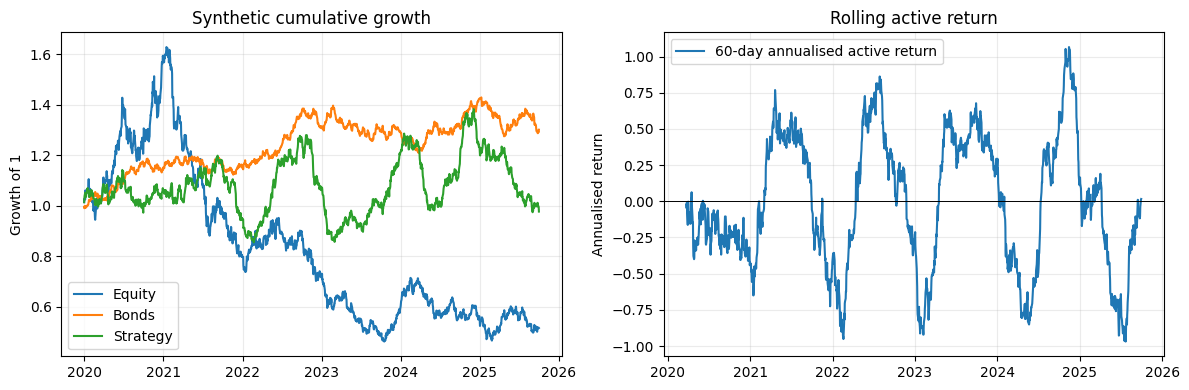

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot((1 + returns["Equity"]).cumprod(), label="Equity")
axes[0].plot((1 + returns["Bonds"]).cumprod(), label="Bonds")
axes[0].plot((1 + strategy_returns).cumprod(), label="Strategy", linewidth=1.5)
axes[0].set(title="Synthetic cumulative growth", ylabel="Growth of 1")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(active_returns.rolling(60).mean() * 252, label="60-day annualised active return")
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set(title="Rolling active return", ylabel="Annualised return")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()
    

## Step 2 - `scipy.stats`: descriptive statistics and distributions

`scipy.stats` provides distributions, summary statistics, random variables, tests, and confidence intervals. In quantitative work, it is especially useful when you want to state the assumptions behind a calculation rather than only calculate a sample mean.

| Tool | What it does | Important parameters |
|---|---|---|
| `stats.describe` | Compact descriptive summary | `nan_policy`: choose how missing values are handled. |
| `stats.skew` / `stats.kurtosis` | Shape of a distribution | `bias=False`: bias-corrected estimate; `fisher=True`: normal distribution has excess kurtosis 0. |
| `stats.t.fit` | Fit a Student-t distribution | Returns degrees of freedom, location, and scale. |
| `stats.t.ppf` | Quantile of a fitted t distribution | `q`: tail probability; lower `q` means a more extreme left-tail quantile. |
    

In [4]:
equity_return = returns["Equity"].to_numpy()
equity_description = stats.describe(equity_return)

descriptive_table = pd.DataFrame(
    {
        "mean": [equity_description.mean],
        "standard deviation": [np.sqrt(equity_description.variance)],
        "skewness": [stats.skew(equity_return, bias=False)],
        "excess kurtosis": [stats.kurtosis(equity_return, fisher=True, bias=False)],
        "minimum": [equity_description.minmax[0]],
        "maximum": [equity_description.minmax[1]],
    },
    index=["Equity daily return"],
)
descriptive_table.style.format("{:.5f}")
    

,mean,standard deviation,skewness,excess kurtosis,minimum,maximum
Equity daily return,-0.00031,0.01604,-0.00512,0.70088,-0.06046,0.07700


In [5]:
# The Student-t family often describes heavy-tailed returns more flexibly than a normal distribution.
degrees_of_freedom, location, scale = stats.t.fit(equity_return)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(equity_return) - 1,
    loc=equity_return.mean(),
    scale=stats.sem(equity_return),
)

print(f"Fitted Student-t degrees of freedom: {degrees_of_freedom:.2f}")
print(f"Fitted location: {location:.5f}")
print(f"Fitted scale: {scale:.5f}")
print("95% confidence interval for the mean daily return:", tuple(round(value, 5) for value in confidence_interval))
    

Fitted Student-t degrees of freedom: 12.27
Fitted location: -0.00028
Fitted scale: 0.01468
95% confidence interval for the mean daily return: (np.float64(-0.00113), np.float64(0.0005))


In [6]:
alpha = 0.05
historical_quantile = np.quantile(equity_return, alpha)
historical_var = -historical_quantile
historical_expected_shortfall = -equity_return[equity_return <= historical_quantile].mean()

fitted_t_var = -(location + scale * stats.t.ppf(alpha, degrees_of_freedom))

print(f"Historical 95% one-day VaR: {historical_var:.2%}")
print(f"Historical 95% expected shortfall: {historical_expected_shortfall:.2%}")
print(f"Student-t parametric 95% VaR: {fitted_t_var:.2%}")
    

Historical 95% one-day VaR: 2.69%
Historical 95% expected shortfall: 3.46%
Student-t parametric 95% VaR: 2.64%


### Hypothesis tests: use an active-return series, not a story

A p-value does not validate an investment strategy. It answers a narrow question under a chosen statistical model. Here we test whether mean synthetic active return is greater than zero, then report a confidence interval. For real returns, serial correlation, multiple testing, costs, and selection bias all need separate treatment.

| Test | Useful question | Important parameters |
|---|---|---|
| `ttest_1samp` | Is the mean of one series different from a benchmark value? | `popmean`: null mean; `alternative`: `two-sided`, `greater`, or `less`. |
| `ttest_ind` | Do two independent samples have different means? | `equal_var=False`: Welch's test, safer when variances differ. |
| `shapiro` | Is a sample compatible with a normal distribution? | `nan_policy`: missing-value handling; do not confuse rejection with economic importance. |
    

In [7]:
active_test = stats.ttest_1samp(active_returns, popmean=0.0, alternative="greater")
active_interval = active_test.confidence_interval(confidence_level=0.95)
normality_test = stats.shapiro(active_returns)

print(f"Active-return t statistic: {active_test.statistic:.3f}")
print(f"One-sided p-value: {active_test.pvalue:.4f}")
print("95% confidence interval for mean active return:", tuple(round(value, 5) for value in active_interval))
print(f"Shapiro-Wilk p-value: {normality_test.pvalue:.4f}")
    

Active-return t statistic: -0.195
One-sided p-value: 0.5772
95% confidence interval for mean active return: (np.float64(-0.00043), np.float64(inf))
Shapiro-Wilk p-value: 0.6426


## Step 3 - `scipy.optimize`: constrained portfolio optimisation

`scipy.optimize.minimize` is the main general-purpose interface for minimising a function. It requires an objective function, starting point, and—when needed—bounds and constraints.

We minimise annualised variance subject to fully invested, long-only weights. `SLSQP` is a practical method for smooth problems with equality and inequality constraints.

| Argument | Meaning |
|---|---|
| `fun` | The scalar objective function to minimise. |
| `x0` | Starting guess for the parameters/weights. |
| `method="SLSQP"` | Optimiser that supports bounds and constraints. |
| `bounds` | Per-weight lower and upper limits. |
| `constraints` | Rules such as weights summing to one. |
| `options["ftol"]` | Convergence tolerance for the objective; smaller can mean more work. |
| `options["maxiter"]` | Maximum number of optimisation iterations. |
    

In [8]:
annualised_mean = returns.mean().to_numpy() * 252
annualised_covariance = returns.cov().to_numpy() * 252
n_assets = len(asset_names)


def portfolio_variance(weights: np.ndarray, covariance: np.ndarray) -> float:
    return float(weights @ covariance @ weights)


def portfolio_statistics(weights: np.ndarray) -> dict[str, float]:
    annual_return = float(weights @ annualised_mean)
    annual_volatility = float(np.sqrt(portfolio_variance(weights, annualised_covariance)))
    return {"annual return": annual_return, "annual volatility": annual_volatility}


equal_weight = np.repeat(1 / n_assets, n_assets)
bounds = [(0.0, 0.60)] * n_assets
fully_invested = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1.0}

minimum_variance_result = optimize.minimize(
    fun=portfolio_variance,
    x0=equal_weight,
    args=(annualised_covariance,),
    method="SLSQP",
    bounds=bounds,
    constraints=fully_invested,
    options={"ftol": 1e-12, "maxiter": 500},
)

if not minimum_variance_result.success:
    raise RuntimeError(minimum_variance_result.message)

minimum_variance_weights = minimum_variance_result.x
pd.Series(minimum_variance_weights, index=asset_names, name="minimum-variance weight").to_frame()
    

,minimum-variance weight
Equity,0.047113
Value,0.082846
Momentum,0.101515
Bonds,0.600000
Commodity,0.168525


In [9]:
portfolio_comparison = pd.DataFrame(
    [
        portfolio_statistics(equal_weight),
        portfolio_statistics(minimum_variance_weights),
    ],
    index=["Equal weight", "Constrained minimum variance"],
)

portfolio_comparison.style.format("{:.2%}")
    

,annual return,annual volatility
Equal weight,-6.33%,12.76%
Constrained minimum variance,-1.32%,5.99%


## Step 4 - `scipy.linalg`: covariance matrices, eigenvalues, and linear systems

`scipy.linalg` contains robust linear-algebra routines. For a symmetric covariance matrix, use `eigh` rather than the more general `eig`: it exploits symmetry and returns real, ordered eigenvalues.

Eigenvalues tell you how much variation each orthogonal risk direction explains. A large first eigenvalue relative to the rest is a compact sign of common-factor risk.
    

In [10]:
eigenvalues, eigenvectors = linalg.eigh(annualised_covariance)
explained_variance = eigenvalues / eigenvalues.sum()

eigenvalue_table = pd.DataFrame(
    {
        "eigenvalue": eigenvalues[::-1],
        "share of covariance variation": explained_variance[::-1],
    },
    index=[f"Risk direction {number}" for number in range(1, n_assets + 1)],
)

eigenvalue_table.style.format({"eigenvalue": "{:.4f}", "share of covariance variation": "{:.1%}"})
    

,eigenvalue,share of covariance variation
Risk direction 1,0.1228,58.4%
Risk direction 2,0.0353,16.8%
Risk direction 3,0.0283,13.5%
Risk direction 4,0.0193,9.2%
Risk direction 5,0.0045,2.2%


In [11]:
# Solve Sigma x = 1 without explicitly computing an inverse.
# Normalising x gives the unconstrained global-minimum-variance weights.
ones = np.ones(n_assets)
unconstrained_solution = linalg.solve(annualised_covariance, ones, assume_a="pos")
unconstrained_gmv_weights = unconstrained_solution / unconstrained_solution.sum()

pd.Series(unconstrained_gmv_weights, index=asset_names, name="unconstrained GMV weight").to_frame()
    

,unconstrained GMV weight
Equity,0.065478
Value,0.046970
Momentum,0.058571
Bonds,0.739646
Commodity,0.089335


### Why `solve` instead of an explicit inverse?

Mathematically, solving `Σx = 1` looks like `x = Σ⁻¹1`. Numerically, solve the system directly. It is generally clearer, more stable, and more efficient than calculating a full inverse only to multiply it once.

The unconstrained solution may contain negative weights. That is not an error: it reflects the absence of long-only constraints. The earlier `SLSQP` solution enforces the implementable bounds.
    

## Step 5 - `scipy.signal`: smoothing and frequency inspection

Signal tools can help inspect smooth or cyclical structure, but they do not create predictive information. Two habits matter in finance:

- Use **causal** filters for features used in a backtest; a centred smoother can look into the future.
- Treat a periodogram as descriptive. A frequency peak is not a tradeable cycle until it survives out-of-sample testing.

| Tool | Use | Important parameters |
|---|---|---|
| `signal.lfilter` | Causal linear filter | numerator/denominator coefficients; a moving average uses equal numerator weights. |
| `signal.periodogram` | Estimate power by frequency | `fs`: observations per unit; `detrend`: remove level/trend; `window`: leakage/variance trade-off. |
    

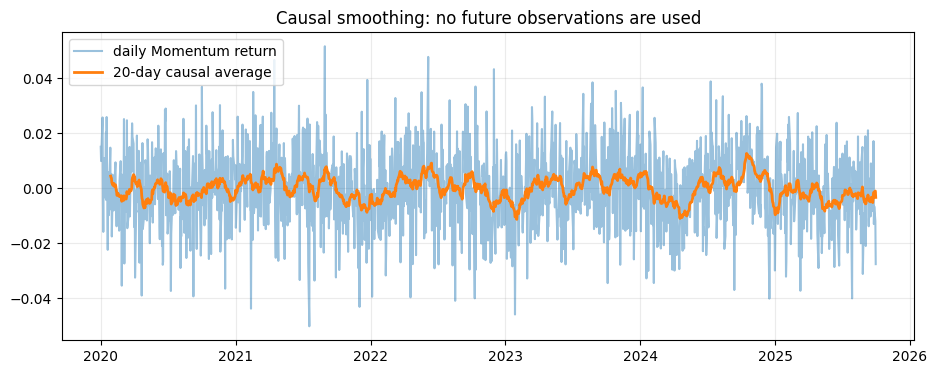

In [12]:
# This one-sided moving average uses only current and past values.
window = 20
moving_average_coefficients = np.ones(window) / window
causal_smoothed_momentum = signal.lfilter(
    moving_average_coefficients,
    [1.0],
    returns["Momentum"].to_numpy(),
)
causal_smoothed_momentum[: window - 1] = np.nan

plt.figure(figsize=(11, 4))
plt.plot(returns.index, returns["Momentum"], alpha=0.45, label="daily Momentum return")
plt.plot(returns.index, causal_smoothed_momentum, linewidth=2, label="20-day causal average")
plt.title("Causal smoothing: no future observations are used")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
    

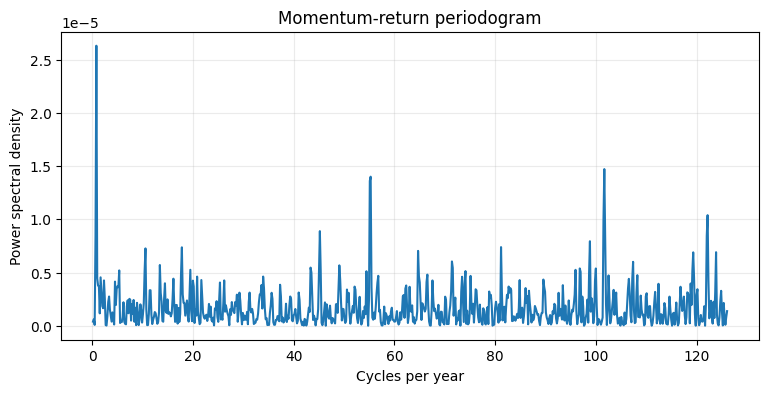

In [13]:
# fs=252 means the frequency unit is cycles per trading year.
frequencies, power = signal.periodogram(
    returns["Momentum"].to_numpy(),
    fs=252,
    detrend="linear",
    window="hann",
)

positive = frequencies > 0
plt.figure(figsize=(9, 4))
plt.plot(frequencies[positive], power[positive])
plt.title("Momentum-return periodogram")
plt.xlabel("Cycles per year")
plt.ylabel("Power spectral density")
plt.grid(alpha=0.25)
plt.show()
    

## Step 6 - `scipy.interpolate` and `scipy.integrate`: zero curves and discounting

Interpolation connects sparse quoted curve points. `PchipInterpolator` is shape-preserving and is often a useful first choice for a smooth curve without the overshoot that can appear in unconstrained cubic splines.

`quad` numerically integrates a one-dimensional function. Here it calculates the present value of a continuously paid unit coupon over five years using an illustrative continuously compounded zero curve.

| Tool | Use | Important parameters |
|---|---|---|
| `PchipInterpolator` | Shape-preserving 1D interpolation | `x`: sorted maturities; `y`: observed values; `extrapolate`: whether to allow values beyond the data range. |
| `CubicSpline` | Smooth cubic interpolation | `bc_type`: boundary behaviour; can overshoot between sparse points. |
| `integrate.quad` | Adaptive numerical integration | function, lower/upper bounds, and tolerances such as `epsabs`. |
    

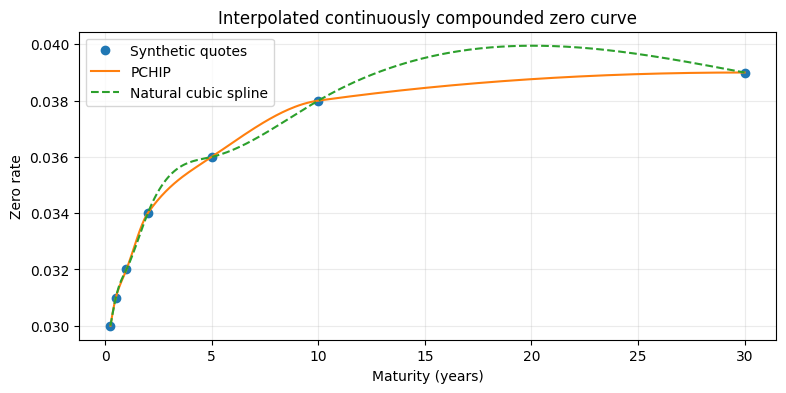

In [14]:
quoted_tenors = np.array([0.25, 0.50, 1.0, 2.0, 5.0, 10.0, 30.0])
quoted_zero_rates = np.array([0.030, 0.031, 0.032, 0.034, 0.036, 0.038, 0.039])

pchip_curve = interpolate.PchipInterpolator(quoted_tenors, quoted_zero_rates, extrapolate=False)
cubic_curve = interpolate.CubicSpline(quoted_tenors, quoted_zero_rates, bc_type="natural")
fine_tenors = np.linspace(quoted_tenors.min(), quoted_tenors.max(), 300)

plt.figure(figsize=(9, 4))
plt.plot(quoted_tenors, quoted_zero_rates, "o", label="Synthetic quotes")
plt.plot(fine_tenors, pchip_curve(fine_tenors), label="PCHIP")
plt.plot(fine_tenors, cubic_curve(fine_tenors), linestyle="--", label="Natural cubic spline")
plt.title("Interpolated continuously compounded zero curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
    

In [15]:
def discount_factor(maturity: float) -> float:
    zero_rate = float(pchip_curve(maturity))
    return np.exp(-zero_rate * maturity)


# Present value of a continuous unit coupon paid from 0.25 to 5 years.
annuity_value, integration_error = integrate.quad(
    lambda maturity: discount_factor(maturity),
    0.25,
    5.0,
    epsabs=1e-10,
)

print(f"Five-year continuous-coupon annuity factor: {annuity_value:.4f}")
print(f"Estimated numerical integration error: {integration_error:.2e}")
    

Five-year continuous-coupon annuity factor: 4.3398
Estimated numerical integration error: 1.23e-08


### Root finding: recover a continuously compounded zero rate

`root_scalar` finds a value that makes a one-dimensional function zero. It is useful for implied rates, yields, and calibration problems. Bracketing methods require an interval where the function changes sign; in return, they are robust.
    

In [16]:
face_value = 100.0
zero_coupon_price = 93.40
maturity = 2.0

implied_rate_result = optimize.root_scalar(
    lambda rate: face_value * np.exp(-rate * maturity) - zero_coupon_price,
    bracket=(0.0, 0.20),
    method="brentq",
)

implied_continuous_rate = implied_rate_result.root
print(f"Implied two-year continuously compounded zero rate: {implied_continuous_rate:.2%}")
    

Implied two-year continuously compounded zero rate: 3.41%


## Common mistakes to remember

- **Using normal VaR mechanically:** return tails can be asymmetric and heavy. Compare empirical and alternative distributional assumptions.
- **Reading a p-value as economic proof:** hypothesis tests do not correct for search bias, serial dependence, costs, or regime changes.
- **Inverting covariance matrices directly:** use `linalg.solve` or a factorisation when you only need a solution.
- **Ignoring optimiser status:** always check `result.success` and inspect constraints/bounds after optimisation.
- **Using centred filters in a backtest:** they leak future observations. Use causal filters for tradable signals.
- **Extrapolating a curve without thought:** interpolation beyond quoted maturities is a model assumption, not a fact.
- **Forgetting units:** daily versus annualised returns, and discrete versus continuous compounding, must stay explicit.
    

## Final takeaway

SciPy is most useful when your question is mathematical rather than purely predictive:

1. use `stats` to describe uncertainty and distributions;
2. use `optimize` to calibrate or solve constrained objectives;
3. use `linalg` to handle matrix problems cleanly;
4. use `signal` to inspect time-series structure without leaking data;
5. use `interpolate`, `integrate`, and root finding to construct curves and price continuous relationships.

The notebook gives you compact patterns to reuse. The official [SciPy user guide](https://docs.scipy.org/doc/scipy/tutorial/) is the right reference when you need a specialised routine or its full parameter list.
    